# Watershed analytics

End-to-end demonstration of the four watershed-partitioning APIs and the/8/9 metric
additions:

* `FlowDirection.watershed(points)` — pour-point delineation.
* `FlowDirection.basins()` — terminal-outlet partition.
* `FlowDirection.subbasins_pfafstetter(max_level=N)` — hierarchical coding.
* `FlowDirection.isobasins(streams, accumulation, target_area_km2)` — equal-area split.
* `WatershedRaster.statistics(flow_direction=...)` — longest_flow_path_m metric.
* `FlowDirection.upslope_flowpath_length()` — per-cell upslope length raster.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80


In [2]:
import numpy as np
import geopandas as gpd
from pyramids.dataset import Dataset
from shapely.geometry import Point
from digitalrivers import DEM

# Build a synthetic catchment: 25×25 grid, V-shaped main valley with two side tributaries.
rows, cols = 25, 25
z = np.full((rows, cols), 200.0, dtype=np.float32)
for r in range(rows):
    z[r, 12] = float(50 - 1.5 * r)  # main stem south
for c in range(12):
    z[8, c] = float(45 - c * 0.5)    # west tributary
for c in range(13, cols):
    z[17, c] = float(30 - (c - 13) * 0.5)

ds = Dataset.create_from_array(
    z, top_left_corner=(500_000.0, 5_000_000.0), cell_size=30.0,
    epsg=32618, no_data_value=-9999.0,
)
dem = DEM(ds.raster)
filled = dem.fill_depressions(method="priority_flood")
fd = filled.flow_direction(method="d8")
acc = fd.accumulate()
streams = acc.streams(threshold=3)
print(f"Stream cells: {int(streams.read_array().astype(bool).sum())}")

2026-05-17 22:36:13 | INFO | pyramids.base.config | Logging is configured.


Stream cells: 45


## Visualise: synthetic DEM with derived stream network

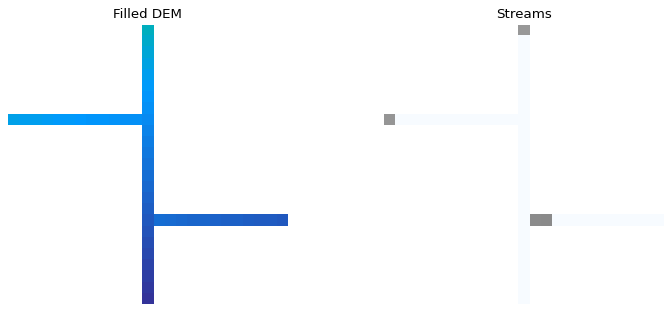

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(filled.values, cmap="terrain", origin="upper")
axes[0].set_title("Filled DEM"); axes[0].axis("off")
axes[1].imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
axes[1].imshow(np.where(streams.read_array().astype(bool), 1, np.nan),
               cmap="Blues", origin="upper")
axes[1].set_title("Streams"); axes[1].axis("off")
fig.tight_layout()
plt.show()


## 1. Pour-point watershed

Place a pour point and delineate everything upstream of it.

In [4]:
gt = fd.geotransform
outlet_row, outlet_col = 24, 12  # south edge of the main stem
outlet_x = gt[0] + (outlet_col + 0.5) * gt[1]
outlet_y = gt[3] + (outlet_row + 0.5) * gt[5]
points = gpd.GeoDataFrame(
    {"id": [1]}, geometry=[Point(outlet_x, outlet_y)], crs=fd.epsg,
)
ws = fd.watershed(points)
print(f"Pour-point watershed cells: {int((ws.read_array() == 1).sum())}")

Pour-point watershed cells: 108


## Visualise: pour-point watershed + outlet marker

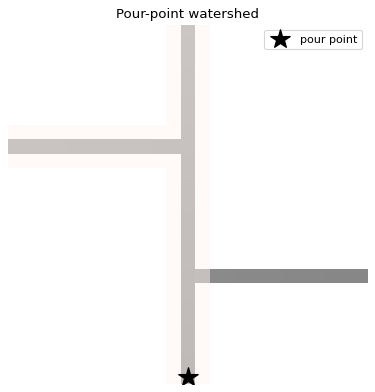

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ws_arr = ws.read_array()
ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
ax.imshow(np.where(ws_arr == 1, 1, np.nan), cmap="Reds", origin="upper", alpha=0.5)
ax.plot(outlet_col, outlet_row, "k*", markersize=18, label="pour point")
ax.set_title("Pour-point watershed"); ax.axis("off"); ax.legend()
fig.tight_layout()
plt.show()


## 2. Terminal-outlet basins

Partition the whole DEM into basins keyed on terminal outlets.

In [6]:
basins = fd.basins()
print(f"Number of basins: {basins.basin_count}")

Number of basins: 486


## 3. Hierarchical Pfafstetter coding

Decimal-digit hierarchy: codes 1/3/5/7/9 = inter-basins; 2/4/6/8 = four largest tributaries
(ordered downstream-most-first).

In [7]:
pfaf = fd.subbasins_pfafstetter(acc, streams, level=2)
codes = np.unique(pfaf.read_array())
codes = codes[codes != 0]
print(f"Pfafstetter codes (max 10 shown): {sorted(set(int(c) for c in codes))[:10]}")

Pfafstetter codes (max 10 shown): [25, 55]


## Visualise: terminal-outlet basins + isobasins

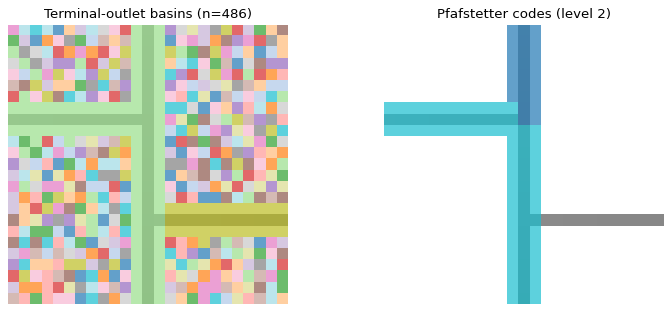

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Random-color basin map for visual contrast
basin_arr = basins.read_array().astype(np.int64)
rng = np.random.default_rng(0)
permutation = rng.permutation(int(basin_arr.max()) + 1).astype(np.float32)
recolour = np.where(basin_arr > 0, permutation[basin_arr], np.nan)
axes[0].imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
axes[0].imshow(recolour, cmap="tab20", origin="upper", alpha=0.7)
axes[0].set_title(f"Terminal-outlet basins (n={basins.basin_count})"); axes[0].axis("off")

# Same for the Pfafstetter coding — colour by digit-code
pfaf_arr = pfaf.read_array()
axes[1].imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
axes[1].imshow(np.where(pfaf_arr > 0, pfaf_arr.astype(float), np.nan),
               cmap="tab10", origin="upper", alpha=0.7)
axes[1].set_title("Pfafstetter codes (level 2)"); axes[1].axis("off")
fig.tight_layout()
plt.show()


## Isobasin equal-area partition

Carve the catchment into sub-basins of approximately equal area. Useful for SWAT / HEC-HMS
modelling where each sub-basin must be ≤ a maximum unit.

In [9]:
cell_area_km2 = abs(gt[1] * gt[5]) / 1.0e6
target = cell_area_km2 * 30  # target ~30 cells per sub-basin
iso = fd.isobasins(streams, acc, target_area_km2=target)
print(f"Target area:    {target * 1.0e6:.0f} m² (~{int(target / cell_area_km2)} cells)")
print(f"Sub-basin count: {iso.basin_count}")

Target area:    27000 m² (~30 cells)
Sub-basin count: 7


## Visualise: equal-area isobasins

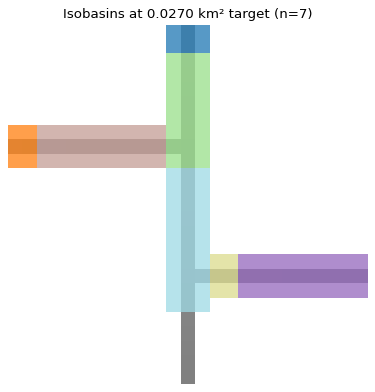

In [10]:
import matplotlib.pyplot as plt

iso_arr = iso.read_array().astype(np.int64)
rng = np.random.default_rng(1)
permutation = rng.permutation(int(iso_arr.max()) + 1).astype(np.float32)
recolour = np.where(iso_arr > 0, permutation[iso_arr], np.nan)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
ax.imshow(recolour, cmap="tab20", origin="upper", alpha=0.75)
ax.set_title(f"Isobasins at {target:.4f} km² target (n={iso.basin_count})")
ax.axis("off")
fig.tight_layout()
plt.show()


## Longest flow path per basin

Post-M1 fix: triggers on `flow_direction` alone. The per-basin metric is the longest
source-to-outlet path within that basin.

In [11]:
stats = basins.statistics(dem=filled, flow_direction=fd, streams=streams)
print(stats[["area_km2", "mean_elev", "longest_flow_path_m", "drainage_density_km_per_km2"]])

          area_km2  mean_elev  longest_flow_path_m  \
basin_id                                             
1           0.0009      200.0                  0.0   
2           0.0009      200.0                  0.0   
3           0.0009      200.0                  0.0   
4           0.0009      200.0                  0.0   
5           0.0009      200.0                  0.0   
...            ...        ...                  ...   
482         0.0009      200.0                  0.0   
483         0.0009      200.0                  0.0   
484         0.0009      200.0                  0.0   
485         0.0009      200.0                  0.0   
486         0.0009      200.0                  0.0   

          drainage_density_km_per_km2  
basin_id                               
1                                 0.0  
2                                 0.0  
3                                 0.0  
4                                 0.0  
5                                 0.0  
...              

## Per-cell upslope flow-path length

Returns a raster of per-cell longest upslope flow path. Used as a building block for
time-of-concentration models, sensitivity analyses, and response-time mapping.

In [12]:
upslope = fd.upslope_flowpath_length()
ups = upslope.read_array()
print(f"Upslope length range: [{ups.min():.1f}, {ups.max():.1f}] m")
print(f"Mean upslope length:  {ups[ups > 0].mean():.1f} m")

Upslope length range: [0.0, 852.4] m
Mean upslope length:  327.3 m


## Visualise: per-cell upslope flow-path length

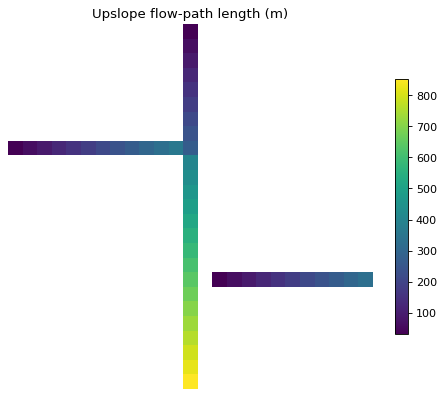

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
show = np.where(ups <= 0, np.nan, ups)
im = ax.imshow(show, cmap="viridis", origin="upper")
ax.set_title("Upslope flow-path length (m)"); ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()


## Summary

Five distinct watershed partitions on the same DEM:
* Pour-point: 1 basin upstream of a chosen outlet.
* Terminal-outlet: every internal sink becomes its own basin.
* Pfafstetter: hierarchical decimal coding.
* Isobasin: approximately equal-area sub-basins.
* Plus per-basin `longest_flow_path_m` and a per-cell upslope length raster.